# MainQuest 07 : U-Net 성능 개선 프로젝트

In [2]:
# 필요 라이브러리 로딩
from __future__ import absolute_import, division
from __future__ import print_function, unicode_literals

import os
import time
import shutil
import functools

import tensorflow
import sklearn
import numpy

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib as mpl
mpl.rcParams['axes.grid'] = False
mpl.rcParams['figure.figsize'] = (12,12)

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.image as mpimg
import pandas as pd
from PIL import Image
from IPython.display import clear_output

import tensorflow as tf
import tensorflow_addons as tfa
print(tf.__version__)

from tensorflow.keras import layers
from tensorflow.keras import losses
from tensorflow.keras import models

2.6.0


In [3]:
DATASET_PATH = os.path.join(os.getenv('HOME'), 'aiffel', 'medical')

img_dir = os.path.join(DATASET_PATH, "train")
label_dir = os.path.join(DATASET_PATH, "train_labels")

In [4]:
x_train_filenames = [os.path.join(img_dir, filename) for filename in os.listdir(img_dir)]
x_train_filenames.sort()
y_train_filenames = [os.path.join(label_dir, filename) for filename in os.listdir(label_dir)]
y_train_filenames.sort()

In [5]:
x_train_filenames, x_test_filenames, y_train_filenames, y_test_filenames = \
                    train_test_split(x_train_filenames, y_train_filenames, test_size=0.2)

In [7]:
num_train_examples = len(x_train_filenames)
num_test_examples = len(x_test_filenames)

print("Number of training examples: {}".format(num_train_examples))
print("Number of test examples: {}".format(num_test_examples))

Number of training examples: 240
Number of test examples: 60


### Visualization

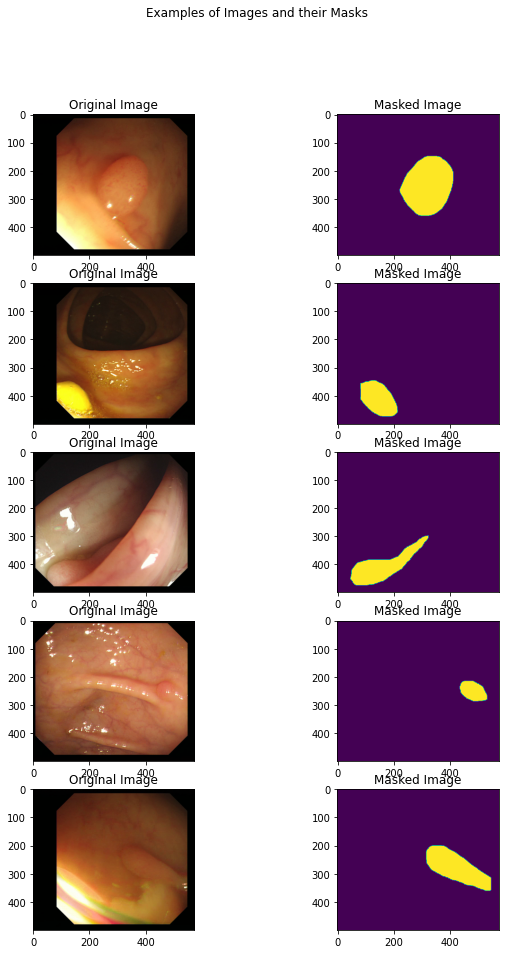

In [8]:
display_num = 5

r_choices = np.random.choice(num_train_examples, display_num)

plt.figure(figsize=(10, 15))
for i in range(0, display_num * 2, 2):
    img_num = r_choices[i // 2]
    x_pathname = x_train_filenames[img_num]
    y_pathname = y_train_filenames[img_num]

    plt.subplot(display_num, 2, i + 1)
    plt.imshow(Image.open(x_pathname))
    plt.title("Original Image")

    example_labels = Image.open(y_pathname)
    label_vals = np.unique(example_labels)

    plt.subplot(display_num, 2, i + 2)
    plt.imshow(example_labels)
    plt.title("Masked Image")
    
plt.suptitle("Examples of Images and their Masks")
plt.show()

### Set up hyper-parameters

In [9]:
# Set hyperparameters

image_size = 256
img_shape = (image_size, image_size, 3)
batch_size = 8
max_epochs = 10

## **Data pipeline and Preprocessing**

Processing each pathname  

In [ ]:
def _process_pathnames(fname, label_path):
    # We map this function onto each pathname pair
    img_str = tf.io.read_file(fname)
    img = tf.image.decode_bmp(img_str, channels=3)

    label_img_str = tf.io.read_file(label_path)
    label_img = tf.image.decode_bmp(label_img_str, channels=3)
    label_img = tf.image.rgb_to_grayscale(label_img)

    resize = [image_size, image_size]
    img = tf.image.resize(img, resize)
    label_img = tf.image.resize(label_img, resize)

    scale = 1 / 255.
    img = tf.cast(img, dtype=tf.float32) * scale
    label_img = tf.cast(label_img, dtype=tf.float32) * scale

    return img, label_img

Data augmentation - Shifting the image  

In [ ]:
def shift_img(output_img, label_img, width_shift_range, height_shift_range):
    """This fn will perform the horizontal or vertical shift"""
    if width_shift_range or height_shift_range:
        if width_shift_range:
                width_shift_range = tf.random.uniform([],
                                                  -width_shift_range * img_shape[1],
                                                  width_shift_range * img_shape[1])
        if height_shift_range:
                height_shift_range = tf.random.uniform([],
                                                   -height_shift_range * img_shape[0],
                                                   height_shift_range * img_shape[0])
        output_img = tfa.image.translate(output_img,
                                         [width_shift_range, height_shift_range])
        label_img = tfa.image.translate(label_img,
                                        [width_shift_range, height_shift_range])
    return output_img, label_img

Data augmentation - Flipping the image randomly  

In [ ]:
def flip_img(horizontal_flip, tr_img, label_img):
    if horizontal_flip:
        flip_prob = tf.random.uniform([], 0.0, 1.0)
        tr_img, label_img = tf.cond(tf.less(flip_prob, 0.5),
                                lambda: (tf.image.flip_left_right(tr_img), tf.image.flip_left_right(label_img)),
                                lambda: (tr_img, label_img))
    return tr_img, label_img

Data augmentation Assembling  

In [ ]:
def _augment(img,
             label_img,
             resize=None,  # Resize the image to some size e.g. [256, 256]
             scale=1,  # Scale image e.g. 1 / 255.
             hue_delta=0.,  # Adjust the hue of an RGB image by random factor
             horizontal_flip=True,  # Random left right flip,
             width_shift_range=0.05,  # Randomly translate the image horizontally
             height_shift_range=0.05):  # Randomly translate the image vertically 
    if resize is not None:
        # Resize both images
        label_img = tf.image.resize(label_img, resize)
        img = tf.image.resize(img, resize)
  
    if hue_delta:
        img = tf.image.random_hue(img, hue_delta)
  
    img, label_img = flip_img(horizontal_flip, img, label_img)
    img, label_img = shift_img(img, label_img, width_shift_range, height_shift_range)
    label_img = tf.cast(label_img, dtype=tf.float32) * scale
    img = tf.cast(img, dtype=tf.float32) * scale
    return img, label_img

### Set up train and test datasets


In [ ]:
def get_baseline_dataset(filenames,
                         labels,
                         preproc_fn=functools.partial(_augment),
                         threads=4,
                         batch_size=batch_size,
                         is_train=True):
    num_x = len(filenames)
    # Create a dataset from the filenames and labels
    dataset = tf.data.Dataset.from_tensor_slices((filenames, labels))
    # Map our preprocessing function to every element in our dataset, taking
    # advantage of multithreading
    dataset = dataset.map(_process_pathnames, num_parallel_calls=threads)

    if is_train:# 학습을 진행할시에만 위에 augment를 진행합니다.
        #if preproc_fn.keywords is not None and 'resize' not in preproc_fn.keywords:
        #  assert batch_size == 1, "Batching images must be of the same size"
        dataset = dataset.map(preproc_fn, num_parallel_calls=threads)
        dataset = dataset.shuffle(num_x * 10)

    dataset = dataset.batch(batch_size)
    return dataset

In [ ]:
train_dataset = get_baseline_dataset(x_train_filenames, # 학습 데이터
                                     y_train_filenames) # 정답 데이터
train_dataset = train_dataset.repeat()
test_dataset = get_baseline_dataset(x_test_filenames,
                                    y_test_filenames,
                                    is_train=False)
train_dataset

### Plot some train data


In [ ]:
for images, labels in train_dataset.take(1):
    # Running next element in our graph will produce a batch of images
    plt.figure(figsize=(10, 10))
    img = images[0]

    plt.subplot(1, 2, 1)
    plt.imshow(img)

    plt.subplot(1, 2, 2)
    plt.imshow(labels[0, :, :, 0])
    plt.show()

## **Build the three model**
### **ED vs Unet vs Pretrained_Unet**

### **1. Encoder-Decoder architecture**


Encoder

In [ ]:
# inputs: [batch_size, 256, 256, 3]
encoder = tf.keras.Sequential(name='encoder')

# conv-batchnorm-activation-maxpool
encoder.add(layers.Conv2D(64, (3, 3), padding='same'))
encoder.add(layers.BatchNormalization())
encoder.add(layers.Activation('relu'))
encoder.add(layers.Conv2D(64, (3, 3), strides=2, padding='same'))
encoder.add(layers.BatchNormalization())
encoder.add(layers.Activation('relu')) # conv1: [batch_size, 128, 128, 64]

encoder.add(layers.Conv2D(128, (3, 3), padding='same'))
encoder.add(layers.BatchNormalization())
encoder.add(layers.Activation('relu'))
encoder.add(layers.Conv2D(128, (3, 3), strides=2, padding='same'))
encoder.add(layers.BatchNormalization())
encoder.add(layers.Activation('relu')) # conv2: [batch_size, 64, 64, 128]

encoder.add(layers.Conv2D(256, (3, 3), padding='same'))
encoder.add(layers.BatchNormalization())
encoder.add(layers.Activation('relu'))
encoder.add(layers.Conv2D(256, (3, 3), strides=2, padding='same'))
encoder.add(layers.BatchNormalization())
encoder.add(layers.Activation('relu')) # conv3: [batch_size, 32, 32, 256]

encoder.add(layers.Conv2D(512, (3, 3), padding='same'))
encoder.add(layers.BatchNormalization())
encoder.add(layers.Activation('relu'))
encoder.add(layers.Conv2D(512, (3, 3), strides=2, padding='same'))
encoder.add(layers.BatchNormalization())
encoder.add(layers.Activation('relu')) # conv4-outputs: [batch_size, 16, 16, 512]

In [ ]:
# Encoder 제대로 만들어졌는지 확인

bottleneck = encoder(tf.random.normal([batch_size, 256, 256, 3]))
print(bottleneck.shape)   # (batch_size, 16, 16, 512) 이 나오는지 확인

Decoder


In [ ]:
# inputs: [batch_size, 16, 16, 512]
decoder = tf.keras.Sequential(name='decoder')

# conv_transpose-batchnorm-activation
decoder.add(layers.Conv2DTranspose(256, (3, 3), strides=2, padding='same'))
decoder.add(layers.BatchNormalization())
decoder.add(layers.Activation('relu')) # conv_transpose1: [batch_size, 32, 32, 256]
decoder.add(layers.Conv2D(256, (3, 3), padding='same'))
decoder.add(layers.BatchNormalization())
decoder.add(layers.Activation('relu'))

decoder.add(layers.Conv2DTranspose(128, (3, 3), strides=2, padding='same'))
decoder.add(layers.BatchNormalization())
decoder.add(layers.Activation('relu')) # conv_transpose2: [batch_size, 64, 64, 128]
decoder.add(layers.Conv2D(128, (3, 3), padding='same'))
decoder.add(layers.BatchNormalization())
decoder.add(layers.Activation('relu'))

decoder.add(layers.Conv2DTranspose(64, (3, 3), strides=2, padding='same'))
decoder.add(layers.BatchNormalization())
decoder.add(layers.Activation('relu')) # conv_transpose3: [batch_size, 128, 128, 64]
decoder.add(layers.Conv2D(64, (3, 3), padding='same'))
decoder.add(layers.BatchNormalization())
decoder.add(layers.Activation('relu'))

decoder.add(layers.Conv2DTranspose(32, (3, 3), strides=2, padding='same'))
decoder.add(layers.BatchNormalization())
decoder.add(layers.Activation('relu')) # conv transpose4-outputs: [batch_size, 256, 256, 32]
decoder.add(layers.Conv2D(32, (3, 3), padding='same'))
decoder.add(layers.BatchNormalization())
decoder.add(layers.Activation('relu'))

decoder.add(layers.Conv2DTranspose(1, 1, strides=1, padding='same', activation='sigmoid'))

In [ ]:
# decoder 제대로 만들어졌는지 확인

predictions = decoder(bottleneck)
print(predictions.shape)    # (batch_size, 256, 256, 1) 이 나오는지 확인

### Create a encoder-decoder model


In [ ]:
ed_model = tf.keras.Sequential()

ed_model.add(encoder)
ed_model.add(decoder)

### **2. U-Net architecture**

오늘 우리가 만들어볼 U-Net 모델구조는 아래 그림과 같습니다. 잘 보면 U-Net 원본과는 약간 차이가 있습니다. 논문 원본의 구현에서는 padding을 zero로 하기 때문에 Encoder 레이어 대비 Decoder 레이어에 약간의 사이즈 축소가 발생합니다. 그러나 우리는 padding을 same으로 두고 Encoder, Decoder간 대응하는 레이어의 사이즈를 동일하게 가져갈 것입니다. 이것은 크게 성능에 영향을 주지 않으면서도 구현이 용이할 뿐더러 이후 모델의 추가개선을 더욱 쉽게 만들어 주는 장점이 있습니다.

content img
Model subclassing을 활용한 구현
U-Net은 Encoder-Decoder 구조와는 달리 해당 레이어의 outputs이 바로 다음 레이어의 inputs이 되지 않습니다. 이럴때는 위에 Encoder-Decoder 모델처럼 tf.keras.Sequential()을 쓸 수가 없게 됩니다.

Sequential 구조가 아닌 네트워크를 만들 때 쓸 수 있는 API 가 바로 tf.keras functional API 입니다. 오늘 우리는 U-Net 구현을 위해 Model subclassing 방식을 사용하여, tf.keras.Model 클래스를 상속하여 구현할 것입니다.

In [ ]:
class Conv(tf.keras.Model):
    def __init__(self, num_filters, kernel_size):
        super(Conv, self).__init__()
        self.conv = layers.Conv2D(num_filters, kernel_size, padding='same')
        self.bn = layers.BatchNormalization()

    def call(self, inputs, training=True):
        x = self.conv(inputs)
        x = self.bn(x, training=training)
        x = layers.ReLU()(x)

        return x

In [ ]:
class ConvBlock(tf.keras.Model):
    def __init__(self, num_filters):
        super(ConvBlock, self).__init__()
        self.conv1 = Conv(num_filters, 3)
        self.conv2 = Conv(num_filters * 2, 3)

    def call(self, inputs, training=True):
        encoder = self.conv1(inputs, training=training)
        encoder = self.conv2(encoder, training=training)

        return encoder

class ConvBlock_R(tf.keras.Model):
    def __init__(self, num_filters):
        super(ConvBlock_R, self).__init__()
        self.conv1 = Conv(num_filters, 3)
        self.conv2 = Conv(num_filters, 3)

    def call(self, inputs, training=True):
        decoder = self.conv1(inputs, training=training)
        decoder = self.conv2(decoder, training=training)

        return decoder


class EncoderBlock(tf.keras.Model):
    def __init__(self, num_filters):
        super(EncoderBlock, self).__init__()
        self.conv_block = ConvBlock(num_filters)
        self.encoder_pool = layers.MaxPool2D()

    def call(self, inputs, training=True):
        encoder = self.conv_block(inputs, training=training)
        encoder_pool = self.encoder_pool(encoder)

        return encoder_pool, encoder


class DecoderBlock(tf.keras.Model):
    def __init__(self, num_filters):
        super(DecoderBlock, self).__init__()
        self.convT = layers.Conv2DTranspose(num_filters, 3, strides=2, padding='same')
        self.bn = layers.BatchNormalization()
        self.conv_block_r = ConvBlock_R(num_filters)

    def call(self, input_tensor, concat_tensor, training=True):
        decoder = self.convT(input_tensor)            
        decoder = self.bn(decoder, training=training)
        decoder = layers.ReLU()(decoder)
        decoder = tf.concat([decoder, concat_tensor], axis=-1)
        decoder = self.conv_block_r(decoder, training=training)

        return decoder

In [ ]:
class UNet(tf.keras.Model):
    def __init__(self):
        super(UNet, self).__init__()
        self.encoder_block1 = EncoderBlock(64)
        self.encoder_block2 = EncoderBlock(128)
        self.encoder_block3 = EncoderBlock(256)
        self.encoder_block4 = EncoderBlock(512)

        self.center = ConvBlock(1024)

        self.decoder_block4 = DecoderBlock(512)
        self.decoder_block3 = DecoderBlock(256)
        self.decoder_block2 = DecoderBlock(128)
        self.decoder_block1 = DecoderBlock(64)

        self.output_conv = layers.Conv2D(1, 1, activation='sigmoid')

    def call(self, inputs, training=True):
        encoder1_pool, encoder1 = self.encoder_block1(inputs)
        encoder2_pool, encoder2 = self.encoder_block2(encoder1_pool)
        encoder3_pool, encoder3 = self.encoder_block3(encoder2_pool)
        encoder4_pool, encoder4 = self.encoder_block4(encoder3_pool)

        center = self.center(encoder4_pool)

        decoder4 = self.decoder_block4(center, encoder4)
        decoder3 = self.decoder_block3(decoder4, encoder3)
        decoder2 = self.decoder_block2(decoder3, encoder2)
        decoder1 = self.decoder_block1(decoder2, encoder1)

        outputs = self.output_conv(decoder1)

        return outputs

### Create a U-Net model

In [ ]:
unet_model = UNet()

## **3. Pretrained U-Net model**


In [ ]:
class Vgg16UNet(tf.keras.Model):
    def __init__(self):
        super(Vgg16UNet, self).__init__()
        self.vgg16 = tf.keras.applications.VGG16(input_shape=img_shape,
                                         include_top=False,
                                         weights='imagenet')
        layer_outputs = [layer.output for layer in self.vgg16.layers]
        self.vgg16_act = models.Model(inputs=self.vgg16.input, 
                                      outputs=[layer_outputs[2], 
                                               layer_outputs[5], 
                                               layer_outputs[9], 
                                               layer_outputs[13], 
                                               layer_outputs[17]])


        self.center = ConvBlock(1024)

        self.decoder_block4 = DecoderBlock(512)
        self.decoder_block3 = DecoderBlock(256)
        self.decoder_block2 = DecoderBlock(128)
        self.decoder_block1 = DecoderBlock(64)

        self.output_conv = layers.Conv2D(1, 1, activation='sigmoid')

    def call(self, inputs, training=True):

        encoder1, encoder2, encoder3, encoder4, center = self.vgg16_act(inputs) 

        decoder4 = self.decoder_block4(center, encoder4)
        decoder3 = self.decoder_block3(decoder4, encoder3)
        decoder2 = self.decoder_block2(decoder3, encoder2)
        decoder1 = self.decoder_block1(decoder2, encoder1)
        
        outputs = self.output_conv(decoder1)

        return outputs

### Create a pretrained_unet model

In [ ]:
pretrained_unet = Vgg16UNet()

### **Model Sumamry**

In [ ]:
print("\n=== ED Model Summary ===")
ed_model.summary()

print("\n=== U-Net Model Summary ===") 
unet_model.summary()

print("\n=== Pretrained U-Net Model Summary ===")
pretrained_unet.summary()

### **Model Configs with checkpoint_dir and history**

In [ ]:
# 1. 모델과 체크포인트 설정
model_configs = {
    'ed': {
        'model': ed_model,
        'checkpoint_dir': os.path.join(DATASET_PATH, 'ed_ckpt/ed_model'),
        'history': None
    },
    'unet': {
        'model': unet_model,
        'checkpoint_dir': os.path.join(DATASET_PATH, 'unet_ckpt/unet_model'),
        'history': None
    },
    'pretrained_unet': {
        'model': pretrained_unet,
        'checkpoint_dir': os.path.join(DATASET_PATH, 'pretrained_ckpt/pretrained_unet_model'),
        'history': None
    }
}


## **metrics과 loss functions 정의하기**

In [ ]:
def dice_coeff(y_true, y_pred):
    smooth = 1e-10
    # Flatten
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    score = (2. * intersection + smooth) / (tf.reduce_sum(tf.square(y_true_f)) + \
                                            tf.reduce_sum(tf.square(y_pred_f)) + smooth)

    return score

In [ ]:
def dice_loss(y_true, y_pred):
    loss = 1 - dice_coeff(y_true, y_pred)
    return loss

In [ ]:
def bce_dice_loss(y_true, y_pred):
    loss = tf.reduce_mean(losses.binary_crossentropy(y_true, y_pred)) + \
          dice_loss(y_true, y_pred)
    return loss

In [ ]:
optimizer = tf.keras.optimizers.Adam() # 기본 Learning rate 사용

### Mean IoU Metric 함수

In [ ]:
def mean_iou(y_true, y_pred, num_classes=2):
    # Flatten  
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    y_true_f = tf.cast(tf.round(y_true_f), dtype=tf.int32).numpy()
    y_pred_f = tf.cast(tf.round(y_pred_f), dtype=tf.int32).numpy()

    # calculate confusion matrix
    labels = list(range(num_classes))
    current = confusion_matrix(y_true_f, y_pred_f, labels=labels)

    # compute mean iou
    intersection = np.diag(current)
    ground_truth_set = current.sum(axis=1)
    predicted_set = current.sum(axis=0)
    union = ground_truth_set + predicted_set - intersection

    IoU = intersection / union.astype(np.float32)
    return np.mean(IoU)

## **Train your model**


### Training-model.fit()







In [ ]:
# 2. 모델 학습 함수
def train_model(model_name):
    model = model_configs[model_name]['model']
    checkpoint_dir = model_configs[model_name]['checkpoint_dir']
    
    # 체크포인트 디렉토리 생성
    if not os.path.isdir(checkpoint_dir):
        os.makedirs(checkpoint_dir)
    
    # 콜백 설정
    cp_callback = tf.keras.callbacks.ModelCheckpoint(
        checkpoint_dir,
        save_weights_only=True,
        monitor='val_loss',
        mode='auto',
        save_best_only=True,
        verbose=0
    )
    
    cos_decay = tf.keras.experimental.CosineDecay(1e-3, max_epochs)
    lr_callback = tf.keras.callbacks.LearningRateScheduler(cos_decay, verbose=1)
    
    # 모델 컴파일
    model.compile(optimizer='adam', loss=bce_dice_loss, metrics=[dice_loss, mean_iou])
    
    # 학습
    history = model.fit(
        train_dataset,
        epochs=max_epochs,
        steps_per_epoch=num_train_examples//batch_size,
        validation_data=test_dataset,
        validation_steps=num_test_examples//batch_size,
        callbacks=[cp_callback, lr_callback]
    )
    
    return history

In [ ]:
# 3. 성능 평가 함수
def evaluate_model(model_name):
    model = model_configs[model_name]['model']
    mean_ious = []
    
    for images, labels in test_dataset:
        predictions = model(images, training=False)
        m = mean_iou(labels, predictions)
        mean_ious.append(m)
    
    return np.mean(mean_ious)

In [ ]:
# 4. 시각화 함수
def visualize_predictions(model_name):
    model = model_configs[model_name]['model']
    
    for test_images, test_labels in test_dataset.take(1):
        predictions = model(test_images, training=False)
        
        for i in range(min(3, batch_size)):  # 처음 3개 이미지만 표시
            plt.figure(figsize=(15, 5))
            
            plt.subplot(1, 3, 1)
            plt.imshow(test_images[i])
            plt.title(f"{model_name}: Input Image")
            
            plt.subplot(1, 3, 2)
            plt.imshow(test_labels[i, :, :, 0])
            plt.title("Ground Truth")
            
            plt.subplot(1, 3, 3)
            plt.imshow(predictions[i, :, :, 0])
            plt.title("Prediction")
            plt.show()


In [ ]:
# 5. 학습 히스토리 시각화 함수
def plot_training_history(model_name):
    history = model_configs[model_name]['history']
    
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Loss')
    plt.plot(history.history['dice_loss'], label='Dice Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.plot(history.history['val_dice_loss'], label='Val Dice Loss')
    plt.title(f'{model_name} Training History - Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['mean_iou'], label='Mean IoU')
    plt.plot(history.history['val_mean_iou'], label='Val Mean IoU')
    plt.title(f'{model_name} Training History - Mean IoU')
    plt.legend()
    plt.show()

In [ ]:
# 6. 모델 비교 실행
def compare_models():
    results = {}
    
    # 각 모델 학습 및 평가
    for model_name in model_configs.keys():
        print(f"\n=== Training {model_name} ===")
        history = train_model(model_name)
        model_configs[model_name]['history'] = history
        
        print(f"\n=== Evaluating {model_name} ===")
        mean_iou_score = evaluate_model(model_name)
        results[model_name] = {
            'mean_iou': mean_iou_score,
            'final_loss': history.history['val_loss'][-1]
        }
        
        print(f"\n=== Visualizing {model_name} results ===")
        visualize_predictions(model_name)
        plot_training_history(model_name)
    
    # 결과 비교 테이블 출력
    print("\n=== Final Results ===")
    for model_name, metrics in results.items():
        print(f"\n{model_name}:")
        print(f"Mean IoU: {metrics['mean_iou']:.4f}")
        print(f"Final Val Loss: {metrics['final_loss']:.4f}")


In [ ]:
# 7. 실행
compare_models()

### 모델 간 성능차이 시각화

In [ ]:
def plot_model_comparison(results):
    models = list(results.keys())
    mean_ious = [results[m]['mean_iou'] for m in models]
    
    plt.figure(figsize=(10, 6))
    plt.bar(models, mean_ious)
    plt.title('Model Comparison - Mean IoU')
    plt.ylabel('Mean IoU')
    plt.show()

## **Restore the latest checkpoint**



## **Evaluate the test dataset**



In [ ]:
# 모델 로드 함수 정의
def load_saved_models():
    model_checkpoints = {
        'ed': os.path.join(DATASET_PATH, 'ed_ckpt/ed_model'),
        'unet': os.path.join(DATASET_PATH, 'unet_ckpt/unet_model'),
        'pretrained_unet': os.path.join(DATASET_PATH, 'pretrained_ckpt/pretrained_unet_model')
    }
    
    loaded_models = {}
    for model_name, checkpoint_path in model_checkpoints.items():
        print(f"\nLoading {model_name} model...")
        if model_name == 'ed':
            model = ed_model
        elif model_name == 'unet':
            model = unet_model
        else:
            model = pretrained_unet
            
        # 모델 컴파일
        model.compile(optimizer='adam',
                     loss=bce_dice_loss,
                     metrics=[dice_loss, mean_iou])
        
        # 저장된 가중치 로드
        try:
            model.load_weights(checkpoint_path)
            print(f"Successfully loaded weights for {model_name}")
            loaded_models[model_name] = model
        except:
            print(f"No saved weights found for {model_name}")
            continue
    
    return loaded_models

# 저장된 모델들을 로드하여 비교
def compare_saved_models():
    # 저장된 모델 로드
    models = load_saved_models()
    
    if not models:
        print("No saved models found!")
        return
        
    # 테스트 데이터로 성능 평가
    results = {}
    for model_name, model in models.items():
        print(f"\nEvaluating {model_name}...")
        mean_ious = []
        
        for images, labels in test_dataset:
            predictions = model(images, training=False)
            m = mean_iou(labels, predictions)
            mean_ious.append(m)
        
        avg_iou = np.mean(mean_ious)
        results[model_name] = avg_iou
        print(f"{model_name} Mean IoU: {avg_iou:.4f}")
    
    # 시각적 비교
    for test_images, test_labels in test_dataset.take(1):
        plt.figure(figsize=(15, 5*len(models)))
        
        for idx, (model_name, model) in enumerate(models.items()):
            predictions = model(test_images, training=False)
            
            # 첫 번째 이미지에 대해서만 비교
            plt.subplot(len(models), 3, idx*3 + 1)
            plt.imshow(test_images[0])
            plt.title(f"{model_name}: Input")
            
            plt.subplot(len(models), 3, idx*3 + 2)
            plt.imshow(test_labels[0, :, :, 0])
            plt.title("Ground Truth")
            
            plt.subplot(len(models), 3, idx*3 + 3)
            plt.imshow(predictions[0, :, :, 0])
            plt.title(f"Prediction (IoU: {results[model_name]:.3f})")
        
        plt.tight_layout()
        plt.show()
    
    # 성능 비교 그래프
    plt.figure(figsize=(10, 6))
    plt.bar(results.keys(), results.values())
    plt.title('Model Performance Comparison')
    plt.ylabel('Mean IoU')
    plt.ylim(0, 1)
    for i, v in enumerate(results.values()):
        plt.text(i, v + 0.01, f'{v:.3f}', ha='center')
    plt.show()

# 실행
compare_saved_models()

# **프로젝트: U-Net 성능 개선해 보기**

### 세 모델의 체계적 비교 분석

In [ ]:
def comprehensive_model_comparison():
    # 1. 학습 과정 비교
    plt.figure(figsize=(15, 5))
    
    # Loss 비교
    plt.subplot(1, 3, 1)
    for model_name in model_configs:
        history = model_configs[model_name]['history']
        plt.plot(history.history['val_loss'], label=model_name)
    plt.title('Validation Loss Comparison')
    plt.legend()
    
    # Mean IoU 비교
    plt.subplot(1, 3, 2)
    for model_name in model_configs:
        history = model_configs[model_name]['history']
        plt.plot(history.history['val_mean_iou'], label=model_name)
    plt.title('Validation Mean IoU Comparison')
    plt.legend()
    
    # Dice Loss 비교
    plt.subplot(1, 3, 3)
    for model_name in model_configs:
        history = model_configs[model_name]['history']
        plt.plot(history.history['val_dice_loss'], label=model_name)
    plt.title('Validation Dice Loss Comparison')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # 2. 최종 성능 비교 테이블
    results_table = {
        'Model': [],
        'Final Val Loss': [],
        'Final Mean IoU': [],
        'Final Dice Loss': []
    }
    
    for model_name in model_configs:
        history = model_configs[model_name]['history']
        results_table['Model'].append(model_name)
        results_table['Final Val Loss'].append(history.history['val_loss'][-1])
        results_table['Final Mean IoU'].append(history.history['val_mean_iou'][-1])
        results_table['Final Dice Loss'].append(history.history['val_dice_loss'][-1])
    
    # 3. 시각적 세그멘테이션 결과 비교
    def compare_segmentation_results():
        for test_images, test_labels in test_dataset.take(1):
            plt.figure(figsize=(15, 5*len(model_configs)))
            for idx, (model_name, config) in enumerate(model_configs.items()):
                predictions = config['model'](test_images, training=False)
                
                # 첫 번째 이미지에 대해서만 비교
                plt.subplot(len(model_configs), 3, idx*3 + 1)
                plt.imshow(test_images[0])
                plt.title(f"{model_name}: Input")
                
                plt.subplot(len(model_configs), 3, idx*3 + 2)
                plt.imshow(test_labels[0, :, :, 0])
                plt.title("Ground Truth")
                
                plt.subplot(len(model_configs), 3, idx*3 + 3)
                plt.imshow(predictions[0, :, :, 0])
                plt.title(f"Prediction (IoU: {mean_iou(test_labels[0:1], predictions[0:1]):.3f})")
            
            plt.tight_layout()
            plt.show()
    
    compare_segmentation_results()

In [ ]:
comprehensive_model_comparison()

STEP 1 : 데이터셋 구성  

오늘 실습에서 활용하였던 Giana 데이터셋을 그대로 활용하여, augmentation을 위한 파이프라인 구성 및 tf.data.Dataset을 이용한 배치처리를 통해 학습/테스트 데이터셋을 구성합니다.



STEP 2 : pretrained model을 활용한 U-Net 모델 구성  

Encoder를 pretrained 모델로 변경하는 작업을 어떻게 진행하면 좋을까요? 아래 예시는 VGG16을 활용하기 위한 것입니다. 마음에 드는 다른 모델을 활용하기 위해 다양하게 시도해 보는 것을 권장합니다.

우선 VGG16 모델의 레이어 구성을 확인해 봅시다. U-Net이란 Encoder와 Decoder 사이의 대응되는 레이어간의 skip connection이 특징인 모델입니다. 여기서 Encoder를 pretrained model로 바꿔주려면 Encoder로 활용할 모델의 레이어 구성을 눈여겨 봐야겠죠?

In [ ]:
class Vgg16UNet(tf.keras.Model):
    def __init__(self):
        super(Vgg16UNet, self).__init__()
        self.vgg16 = tf.keras.applications.VGG16(input_shape=img_shape,
                                         include_top=False,
                                         weights='imagenet')
        layer_outputs = [layer.output for layer in self.vgg16.layers]
        self.vgg16_act = models.Model(inputs=self.vgg16.input, 
                                      outputs=[layer_outputs[2], 
                                               layer_outputs[5], 
                                               layer_outputs[9], 
                                               layer_outputs[13], 
                                               layer_outputs[17]])


        self.center = ConvBlock(1024)

        self.decoder_block4 = DecoderBlock(512)
        self.decoder_block3 = DecoderBlock(256)
        self.decoder_block2 = DecoderBlock(128)
        self.decoder_block1 = DecoderBlock(64)

        self.output_conv = layers.Conv2D(1, 1, activation='sigmoid')

    def call(self, inputs, training=True):

        encoder1, encoder2, encoder3, encoder4, center = self.vgg16_act(inputs) 

        decoder4 = self.decoder_block4(center, encoder4)
        decoder3 = self.decoder_block3(decoder4, encoder3)
        decoder2 = self.decoder_block2(decoder3, encoder2)
        decoder1 = self.decoder_block1(decoder2, encoder1)
        
        outputs = self.output_conv(decoder1)

        return outputs

STEP 3 : 학습과 테스트, 시각화   

모델을 변경하여 실습과정과 동일하게 학습과 테스트, 시각화를 진행합니다.

STEP 4 : 모델 성능 비교분석  

Encoder-Decoder 모델, U-Net 모델, Pretrained U-Net 모델 이상 3가지에 대해 학습 진행과정, 정량/정성적 테스트 결과를 포함한 비교분석을 진행하여 봅니다.

### 평가 루브릭
평가문항	상세기준
1. 의료영상 데이터의 전처리 및 augmentation을 위한 파이프라인 구성이 체계적으로 진행되었는가?	augmentation이 반영된 tf.data.Dataset 구성이 정상적으로 진행되었다.
2. U-Net의 개선 모델을 구현하여 적용 후 기존 U-Net 대비 성능 개선을 확인하였는가?	U-Net 개선 모델의 학습 과정이 정상적으로 진행되었으며, validation meanIoU가 기존 U-Net보다 좋아짐을 확인하였다.
3. 3가지 모델에 대한 학습과정, 테스트 결과를 체계적으로 비교분석하였는가?	loss 그래프, meanIoU 계산, segmentation 결과 시각화 등이 3가지 모델에 대해 수행된 후 결과 비교분석이 제시되었다.